# Week 5 — Incremental Classification Algorithms
## LU3.2 — Classification in Data Streams

### ❓ Big Question
**How can a classifier learn one observation at a time?**

**Estimated laboratory time:** ~1h15  
**Core loop:** **PREDICT → EVALUATE → LEARN**

This lab keeps the Week 4 evaluation protocol fixed and changes the **learner**. We will look *inside* several incremental classifiers and ask:

> **What exactly changes inside the model after each labelled observation?**

We will use three lenses:

1. **Parameter evolution** — statistics and coefficients change.
2. **Architecture evolution** — the model can grow new structure.
3. **Dimensionality & cost** — more features affect time, memory, and complexity.

## Learning map

| Learner | Main state that evolves | Architecture can grow? |
|---|---|---:|
| Gaussian Naive Bayes | counts, means, variances | No |
| Online Logistic Regression | weights + bias | No |
| Passive-Aggressive | weights, conditionally | No |
| Hoeffding Tree / VFDT | leaf statistics + tree nodes | **Yes** |
| Public `evolvingfuzzysystems.ENFS_Uni0` implementation | rule parameters + consequents + rule base | **Yes** |

> **Important scientific note.** In this laboratory, `ENFS_Uni0` means the **current public Python implementation distributed by `evolvingfuzzysystems`**. We use it to study evolving fuzzy-rule behaviour, but we do **not** claim that this public implementation is mathematically identical to every equation or update mechanism in the original ENFS-Uni0 paper.

The goal is therefore not to ask *“which model wins?”*, but:

> **What changes inside each learner as new evidence arrives?**

## 0. Setup

The intended libraries are:

```bash
pip install river evolvingfuzzysystems
```

The notebook **does not install packages automatically**. If one of these packages is missing, it activates a clearly labelled educational fallback so that the notebook can still be read and executed. For the classroom experiment, however, use the real packages whenever possible.

### Reproducibility note for the fuzzy model

The public package version should be recorded when you run the notebook. The experiment refers to the **public library implementation** — not to an asserted exact reproduction of the original ENFS-Uni0 paper.

Why this distinction matters:

- a scientific paper defines a mathematical algorithm;
- a software library defines a concrete implementation;
- the two should only be treated as equivalent after the implementation has been verified against the reference formulation.

This is also a useful research lesson: **benchmark the implementation you actually ran, and name it precisely.**

In [1]:
import os
import math
import warnings
import importlib.util
import importlib.metadata as importlib_metadata
from collections import deque
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

RIVER_AVAILABLE = importlib.util.find_spec("river") is not None
EFS_AVAILABLE = importlib.util.find_spec("evolvingfuzzysystems") is not None
SAVE_FIGURES = os.getenv("WEEK05_SAVE_FIGURES", "0") == "1"
FIG_DIR = os.getenv("WEEK05_FIG_DIR", "/mnt/data/week05_build/figures")

if SAVE_FIGURES:
    os.makedirs(FIG_DIR, exist_ok=True)

print(f"River available: {RIVER_AVAILABLE}")
print(f"evolvingfuzzysystems available: {EFS_AVAILABLE}")
for pkg in ("river", "evolvingfuzzysystems"):
    try:
        print(f"{pkg} version: {importlib_metadata.version(pkg)}")
    except importlib_metadata.PackageNotFoundError:
        pass
if not (RIVER_AVAILABLE and EFS_AVAILABLE):
    print("\n⚠️ Educational fallbacks are active in this environment.")
    print("   For the intended course implementation, install: pip install river evolvingfuzzysystems")


def finish_figure(filename):
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(os.path.join(FIG_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

River available: True
evolvingfuzzysystems available: True
river version: 0.26.1
evolvingfuzzysystems version: 0.1.5


### Week 4 → Week 5

Week 4 taught us how the **metric state** evolves. This week the same principle moves inside the learner:

```text
old model state + (x_t, y_t)  →  new model state
```

The protocol stays chronological:

```text
PREDICT  →  EVALUATE  →  LEARN
```

The only thing we change from experiment to experiment is the learner.

In [2]:
def make_parameter_stream(n_samples=700, seed=42):
    """2D nonlinear stream for parameter-evolution demonstrations.

    This stream is intentionally simple and visual. It is used for GaussianNB,
    Logistic Regression, and Passive-Aggressive parameter updates.
    """
    local_rng = np.random.default_rng(seed)
    X = local_rng.uniform(0.0, 1.0, size=(n_samples, 2))
    centered = X - 0.5
    radius = centered[:, 0] ** 2 + 0.75 * centered[:, 1] ** 2
    y = (radius > np.median(radius)).astype(int)
    return [
        {"i": i, "x": {"x0": float(X[i, 0]), "x1": float(X[i, 1])}, "y": int(y[i])}
        for i in range(n_samples)
    ]


def make_architecture_stream(samples_per_region=180, seed=42):
    """Sequential 2D regions designed to make structural evolution observable.

    Four compact regions arrive one after another. Their labels form an XOR-like
    concept, so a single linear boundary is insufficient and a decision tree has
    a reason to grow. The sequential arrival also gives an evolving fuzzy system
    genuinely new regions to represent.

    All values are clipped to [0, 1], which is appropriate for the public fuzzy
    implementation's distance/membership calculations.
    """
    local_rng = np.random.default_rng(seed)
    regions = [
        ((0.18, 0.18), 0),
        ((0.18, 0.82), 1),
        ((0.82, 0.18), 1),
        ((0.82, 0.82), 0),
    ]
    events = []
    i = 0
    for (cx, cy), label in regions:
        X = local_rng.normal(loc=(cx, cy), scale=(0.055, 0.055), size=(samples_per_region, 2))
        X = np.clip(X, 0.0, 1.0)
        for row in X:
            events.append({"i": i, "x": {"x0": float(row[0]), "x1": float(row[1])}, "y": int(label)})
            i += 1
    return events


def make_informative_dimension_stream(n_samples=500, n_features=2, seed=42):
    """Dimensionality experiment where *every* feature contributes to the label.

    This measures increasing input dimensionality rather than injecting irrelevant
    dimensions. Each feature contributes equally to a balanced linear score.
    """
    if n_features < 2:
        raise ValueError("n_features must be >= 2")
    local_rng = np.random.default_rng(seed)
    X = local_rng.uniform(0.0, 1.0, size=(n_samples, n_features))
    score = np.mean(X, axis=1)
    y = (score > np.median(score)).astype(int)
    return [
        {"i": i, "x": {f"x{j}": float(X[i, j]) for j in range(n_features)}, "y": int(y[i])}
        for i in range(n_samples)
    ]


def make_nuisance_stream(n_samples=500, n_features=2, seed=42):
    """Separate stress test: 2 informative features + optional irrelevant features."""
    if n_features < 2:
        raise ValueError("n_features must be >= 2")
    local_rng = np.random.default_rng(seed)
    base = local_rng.uniform(0.0, 1.0, size=(n_samples, 2))
    centered = base - 0.5
    radius = centered[:, 0] ** 2 + 0.75 * centered[:, 1] ** 2
    y = (radius > np.median(radius)).astype(int)
    if n_features > 2:
        noise = local_rng.uniform(0.0, 1.0, size=(n_samples, n_features - 2))
        X = np.column_stack([base, noise])
    else:
        X = base
    return [
        {"i": i, "x": {f"x{j}": float(X[i, j]) for j in range(n_features)}, "y": int(y[i])}
        for i in range(n_samples)
    ]


# Backwards-compatible name used by the parameter-evolution cells.
def make_stream(n_samples=700, n_features=2, seed=42):
    if n_features == 2:
        return make_parameter_stream(n_samples=n_samples, seed=seed)
    return make_nuisance_stream(n_samples=n_samples, n_features=n_features, seed=seed)


def _metrics_from_counts(tp, tn, fp, fn):
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0.0
    p1 = tp / (tp + fp) if (tp + fp) else 0.0
    r1 = tp / (tp + fn) if (tp + fn) else 0.0
    f1_1 = 2*p1*r1/(p1+r1) if (p1+r1) else 0.0
    p0 = tn / (tn + fn) if (tn + fn) else 0.0
    r0 = tn / (tn + fp) if (tn + fp) else 0.0
    f1_0 = 2*p0*r0/(p0+r0) if (p0+r0) else 0.0
    return accuracy, (f1_0 + f1_1) / 2


class StreamingBinaryEvaluator:
    def __init__(self, window_size=100):
        self.tp = self.tn = self.fp = self.fn = 0
        self.cold_starts = 0
        self.recent = deque(maxlen=window_size)

    def update(self, y_true, y_pred):
        if y_pred is None:
            self.cold_starts += 1
            return self.snapshot()
        y_true, y_pred = int(y_true), int(y_pred)
        if y_true == 1 and y_pred == 1: self.tp += 1
        elif y_true == 0 and y_pred == 0: self.tn += 1
        elif y_true == 0 and y_pred == 1: self.fp += 1
        elif y_true == 1 and y_pred == 0: self.fn += 1
        self.recent.append((y_true, y_pred))
        return self.snapshot()

    def snapshot(self):
        accuracy, macro_f1 = _metrics_from_counts(self.tp, self.tn, self.fp, self.fn)
        rtp = rtn = rfp = rfn = 0
        for yt, yp in self.recent:
            if yt == 1 and yp == 1: rtp += 1
            elif yt == 0 and yp == 0: rtn += 1
            elif yt == 0 and yp == 1: rfp += 1
            elif yt == 1 and yp == 0: rfn += 1
        wacc, wf1 = _metrics_from_counts(rtp, rtn, rfp, rfn)
        return {
            "accuracy": accuracy, "macro_f1": macro_f1,
            "window_accuracy": wacc, "window_macro_f1": wf1,
            "evaluated": self.tp + self.tn + self.fp + self.fn,
            "cold_starts": self.cold_starts,
        }


def prequential_trace(events, model, window_size=100):
    evaluator = StreamingBinaryEvaluator(window_size=window_size)
    history = []
    pred_seconds = update_seconds = 0.0
    for row in events:
        t0 = perf_counter()
        y_pred = model.predict_one(row["x"])
        pred_seconds += perf_counter() - t0

        snap = evaluator.update(row["y"], y_pred)   # EVALUATE FIRST

        t1 = perf_counter()
        model.learn_one(row["x"], row["y"])        # LEARN SECOND
        update_seconds += perf_counter() - t1

        history.append({"i": row["i"], **snap})
    return pd.DataFrame(history), evaluator.snapshot(), pred_seconds, update_seconds

## 1. Build a visible 2D parameter-learning stream (~7 min)

We begin with only **2 features** because we want to see the geometry and the movement of model parameters.

This first stream is used only for **parameter evolution**. Later, architecture evolution will receive a different stream deliberately designed to create genuinely new regions.

> **Experimental design matters:** one stream does not have to answer every scientific question.

In [3]:
events_2d = make_stream(n_samples=700, n_features=2, seed=SEED)
df_2d = pd.DataFrame([
    {"i": r["i"], "x0": r["x"]["x0"], "x1": r["x"]["x1"], "y": r["y"]}
    for r in events_2d
])

display(df_2d.head())
print(df_2d["y"].value_counts().sort_index())

,i,x0,x1,y
0,0,0.773956,0.438878,0
1,1,0.858598,0.697368,1
2,2,0.094177,0.975622,1
3,3,0.761140,0.786064,0
4,4,0.128114,0.450386,0


y
0    350
1    350
Name: count, dtype: int64


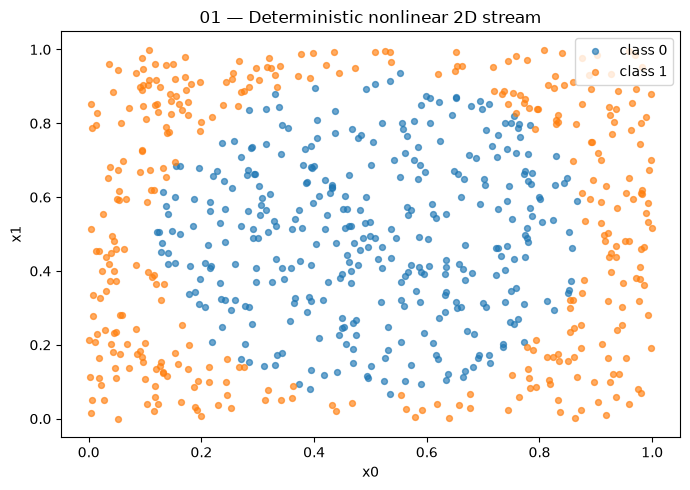

In [4]:
plt.figure(figsize=(7, 5))
for cls, part in df_2d.groupby("y"):
    plt.scatter(part["x0"], part["x1"], s=18, alpha=0.65, label=f"class {cls}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("01 — Deterministic nonlinear 2D stream")
plt.legend()
finish_figure("01_stream_2d.png")

### Exercise 1 — Why use more than one synthetic stream?

Why is it scientifically better to use one controlled stream for **parameter evolution** and another for **architecture evolution**, instead of forcing one dataset to demonstrate everything?

<details>
<summary><strong>Show suggested answer</strong></summary>

Because each experiment should isolate the mechanism we want to observe. A stream that is excellent for showing a moving linear boundary may give a Hoeffding Tree no reason to split. A stream that introduces new compact regions is much better for studying structural growth. Experimental design should match the research question.

</details>

# Part I — Parameter evolution
## 2. Gaussian Naive Bayes: distributions evolve (~10 min)

A Gaussian Naive Bayes learner can summarize each class using compact sufficient statistics:

- class count;
- feature means;
- feature variances.

> **The model remembers distributions, not observations.**

In [5]:
# Intended implementation: River GaussianNB. Fallback: sklearn partial_fit wrapper.
if RIVER_AVAILABLE:
    from river import naive_bayes, linear_model, optim, tree
    RiverGaussianNB = naive_bayes.GaussianNB
    RiverLogisticRegression = linear_model.LogisticRegression
    RiverPAClassifier = linear_model.PAClassifier
    RiverHoeffdingTreeClassifier = tree.HoeffdingTreeClassifier
else:
    from sklearn.naive_bayes import GaussianNB as SkGaussianNB
    from sklearn.linear_model import SGDClassifier
    from sklearn.tree import DecisionTreeClassifier

if EFS_AVAILABLE:
    from evolvingfuzzysystems.classification import ENFS_Uni0


class SkIncrementalAdapter:
    def __init__(self, estimator, n_features):
        self.estimator = estimator
        self.n_features = n_features
        self.initialized = False
        self.observed_classes = set()

    def _row(self, x):
        return np.array([[x[f"x{i}"] for i in range(self.n_features)]], dtype=float)

    def predict_one(self, x):
        if not self.initialized:
            return None
        # Avoid noisy GaussianNB single-class warnings during early fallback steps.
        if len(self.observed_classes) == 1:
            return int(next(iter(self.observed_classes)))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return int(self.estimator.predict(self._row(x))[0])

    def learn_one(self, x, y):
        X, yy = self._row(x), np.array([int(y)])
        self.observed_classes.add(int(y))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if not self.initialized:
                self.estimator.partial_fit(X, yy, classes=np.array([0, 1]))
                self.initialized = True
            else:
                self.estimator.partial_fit(X, yy)
        return self

    @property
    def weights(self):
        if self.initialized and hasattr(self.estimator, "coef_"):
            row = np.asarray(self.estimator.coef_)[0]
            return {f"x{i}": float(row[i]) for i in range(self.n_features)}
        return {}

    @property
    def intercept(self):
        if self.initialized and hasattr(self.estimator, "intercept_"):
            return float(np.asarray(self.estimator.intercept_).ravel()[0])
        return 0.0


def make_gaussian_nb(n_features):
    if RIVER_AVAILABLE:
        return RiverGaussianNB()
    return SkIncrementalAdapter(SkGaussianNB(), n_features)


def make_logistic(n_features, seed=42):
    if RIVER_AVAILABLE:
        return RiverLogisticRegression(optimizer=optim.SGD(0.05))
    return SkIncrementalAdapter(
        SGDClassifier(loss="log_loss", learning_rate="constant", eta0=0.05,
                      random_state=seed, tol=None), n_features)


def make_pa(n_features, seed=42):
    if RIVER_AVAILABLE:
        return RiverPAClassifier(C=0.5, mode=1)
    # scikit-learn 1.8 recommends this PA-I SGD configuration.
    return SkIncrementalAdapter(
        SGDClassifier(loss="hinge", penalty=None, learning_rate="pa1", eta0=1.0,
                      random_state=seed, tol=None), n_features)


class RunningClassGaussianState:
    """Transparent teaching mirror of class-wise sufficient statistics."""
    def __init__(self, n_features):
        self.n_features = n_features
        self.count = {0: 0, 1: 0}
        self.mean = {0: np.zeros(n_features), 1: np.zeros(n_features)}
        self.M2 = {0: np.zeros(n_features), 1: np.zeros(n_features)}

    def update(self, x, y):
        v = np.array([x[f"x{i}"] for i in range(self.n_features)])
        y = int(y)
        self.count[y] += 1
        n = self.count[y]
        delta = v - self.mean[y]
        self.mean[y] += delta / n
        self.M2[y] += delta * (v - self.mean[y])

    def snapshot(self):
        out = {}
        for y in (0, 1):
            n = self.count[y]
            out[y] = {
                "count": n,
                "mean": self.mean[y].copy(),
                "variance": self.M2[y] / n if n else np.zeros(self.n_features),
            }
        return out

In [6]:
checkpoints = [10, 50, 200, 500]
gnb = make_gaussian_nb(2)
gnb_state = RunningClassGaussianState(2)
gnb_snapshots = {}

for k, row in enumerate(events_2d, start=1):
    _ = gnb.predict_one(row["x"])
    gnb.learn_one(row["x"], row["y"])
    gnb_state.update(row["x"], row["y"])
    if k in checkpoints:
        gnb_snapshots[k] = gnb_state.snapshot()

rows = []
for k, snap in gnb_snapshots.items():
    for cls in (0, 1):
        rows.append({
            "n": k, "class": cls, "count": snap[cls]["count"],
            "mean_x0": snap[cls]["mean"][0], "mean_x1": snap[cls]["mean"][1],
            "var_x0": snap[cls]["variance"][0], "var_x1": snap[cls]["variance"][1],
        })
gnb_state_df = pd.DataFrame(rows)
display(gnb_state_df)

,n,class,count,mean_x0,mean_x1,var_x0,var_x1
0,10,0,6,0.596353,0.559499,0.059514,0.043783
1,10,1,4,0.469540,0.665893,0.077311,0.131868
2,50,0,31,0.502887,0.516647,0.047505,0.037830
3,50,1,19,0.443267,0.454960,0.110237,0.135848
4,200,0,110,0.513354,0.491168,0.041687,0.045963
5,200,1,90,0.445530,0.533593,0.127126,0.121549
6,500,0,255,0.508836,0.488198,0.040020,0.043803
7,500,1,245,0.467484,0.524085,0.140595,0.117011


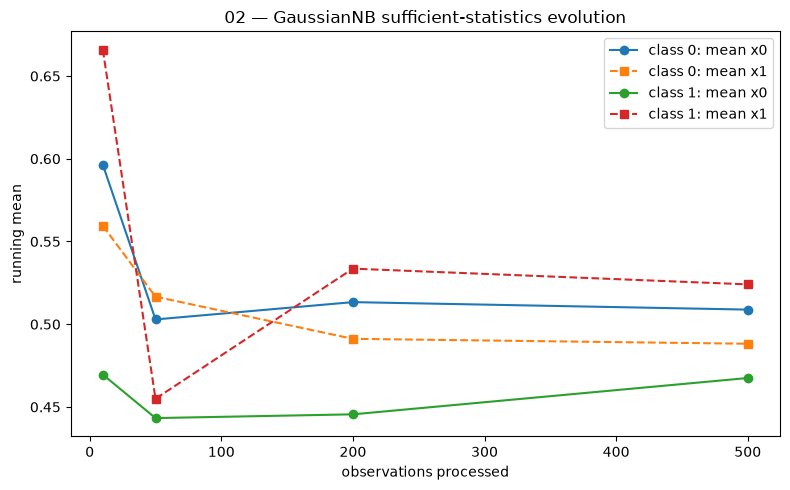

In [7]:
plt.figure(figsize=(8, 5))
for cls in (0, 1):
    part = gnb_state_df[gnb_state_df["class"] == cls]
    plt.plot(part["n"], part["mean_x0"], marker="o", label=f"class {cls}: mean x0")
    plt.plot(part["n"], part["mean_x1"], marker="s", linestyle="--", label=f"class {cls}: mean x1")
plt.xlabel("observations processed")
plt.ylabel("running mean")
plt.title("02 — GaussianNB sufficient-statistics evolution")
plt.legend()
finish_figure("02_gaussiannb_statistics_evolution.png")

### Exercise 2 — What is actually stored?

Why can GaussianNB learn incrementally without keeping the original 500 observations?

<details>
<summary><strong>Show suggested answer</strong></summary>

For Gaussian features, the learner can update class counts, means, and variances incrementally. Those summaries are sufficient for its probability model. The raw observations are not required after they have updated the statistics.

</details>

## 3. Online Logistic Regression: coefficients evolve (~10 min)

A linear classifier keeps a compact parameter vector. Every labelled observation can nudge the decision boundary.

> **Online learning is not one big fit — it is many small corrections.**

In [8]:
def model_coefficients(model, feature_names):
    weights = getattr(model, "weights", {})
    if isinstance(weights, dict):
        w = np.array([float(weights.get(name, 0.0)) for name in feature_names])
    else:
        w = np.zeros(len(feature_names))
    b = float(getattr(model, "intercept", 0.0))
    return w, b

log_model = make_logistic(2, seed=SEED)
log_snapshots = {}
for k, row in enumerate(events_2d, start=1):
    _ = log_model.predict_one(row["x"])
    log_model.learn_one(row["x"], row["y"])
    if k in checkpoints:
        log_snapshots[k] = model_coefficients(log_model, ["x0", "x1"])

pd.DataFrame([
    {"n": k, "w0": wb[0][0], "w1": wb[0][1], "bias": wb[1]}
    for k, wb in log_snapshots.items()
])

,n,w0,w1,bias
0,10,-0.042027,-0.017253,-0.009866
1,50,-0.151442,-0.155606,-0.048660
2,200,-0.287548,-0.035263,-0.056445
3,500,-0.073151,0.287587,0.034114


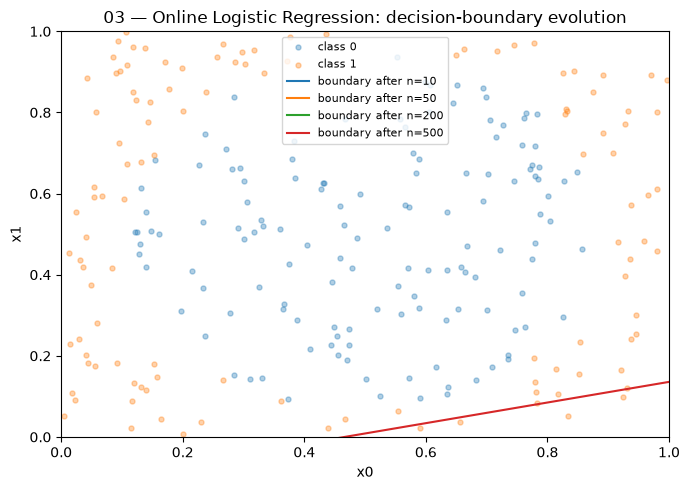

In [9]:
plt.figure(figsize=(7, 5))
# A small stream sample provides context without hiding the boundaries.
sample = df_2d.iloc[:250]
for cls, part in sample.groupby("y"):
    plt.scatter(part["x0"], part["x1"], s=13, alpha=0.35, label=f"class {cls}")

xs = np.linspace(0, 1, 150)
for k, (w, b) in log_snapshots.items():
    if abs(w[1]) > 1e-9:
        ys = -(w[0] * xs + b) / w[1]
        plt.plot(xs, ys, label=f"boundary after n={k}")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("03 — Online Logistic Regression: decision-boundary evolution")
plt.legend(fontsize=8)
finish_figure("03_logistic_boundary_evolution.png")

## 4. Passive-Aggressive: learning only when needed (~8 min)

Passive-Aggressive (PA) gives us a useful contrast:

- if the current margin is sufficient → **passive**;
- if the current example violates the margin → **aggressive update**.

The architecture is still fixed. Only the weights change — but not necessarily after every observation.

In [10]:
pa_model = make_pa(2, seed=SEED)
pa_changes = []
previous_w = np.zeros(2)
changed_count = 0

for k, row in enumerate(events_2d[:250], start=1):
    _ = pa_model.predict_one(row["x"])
    pa_model.learn_one(row["x"], row["y"])
    current_w, _ = model_coefficients(pa_model, ["x0", "x1"])
    changed = not np.allclose(previous_w, current_w)
    changed_count += int(changed)
    pa_changes.append({"i": k, "changed": changed, "cumulative_updates": changed_count})
    previous_w = current_w.copy()

pa_changes_df = pd.DataFrame(pa_changes)
print(f"Material coefficient changes in first 250 events: {changed_count}/250")
display(pa_changes_df.tail())

Material coefficient changes in first 250 events: 193/250


,i,changed,cumulative_updates
245,246,False,193
246,247,False,193
247,248,False,193
248,249,False,193
249,250,False,193


### Exercise 3 — Same architecture, different update rules

Logistic Regression and Passive-Aggressive are both linear. Why can their learning trajectories still differ substantially?

<details>
<summary><strong>Show suggested answer</strong></summary>

They use different update rules and objectives. Online logistic learning typically makes gradient-based corrections, whereas Passive-Aggressive reacts strongly to margin violations and can remain unchanged when the current example is already satisfactory. Same model family does not mean the same learning dynamics.

</details>

# Part II — Architecture evolution
## 5. Hoeffding Tree: when evidence changes the structure (~15 min)

Linear learners move parameters inside a fixed architecture. A stream decision tree faces a harder problem:

> **When is there enough evidence to create structure?**

For this section we deliberately change the stream. Four compact 2D regions arrive sequentially and form an XOR-like concept. This gives the tree a genuine reason to create splits.

We also use **majority-class leaf prediction (`mc`)** here. That choice is intentional: if we used Naive Bayes adaptive leaves, a single unsplit leaf could already classify surprisingly well, hiding the structural-learning mechanism that this experiment is supposed to demonstrate.

> **Pedagogical goal:** here the curve of `n_nodes`, `n_leaves`, and `height` should actually move.

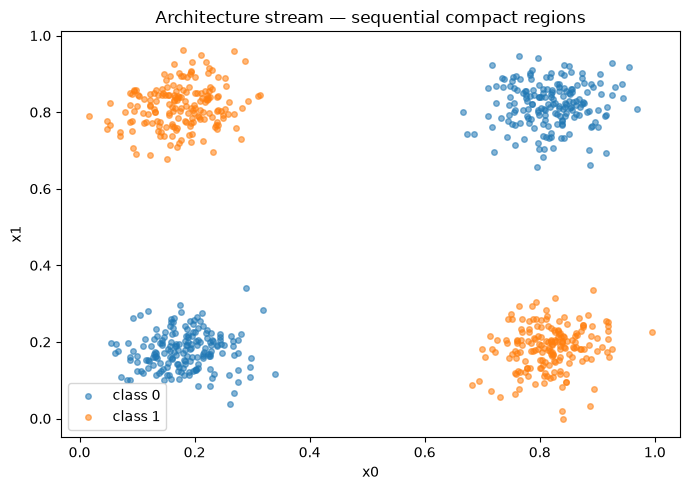

,n,n_nodes,n_leaves,height,accuracy
0,50,1,1,1,1.000000
1,180,1,1,1,1.000000
2,360,3,2,2,0.944290
3,540,5,3,3,0.628942
4,720,7,4,3,0.694019


In [11]:
class FallbackGrowingTree:
    """Educational structural-growth fallback; NOT a Hoeffding/VFDT implementation."""
    def __init__(self, n_features, grace_period=20, seed=42, max_buffer=800):
        from sklearn.tree import DecisionTreeClassifier
        self.n_features = n_features
        self.grace_period = grace_period
        self.seed = seed
        self.max_buffer = max_buffer
        self.X, self.y = [], []
        self.seen = 0
        self.fitted = False
        self.model = DecisionTreeClassifier(max_depth=1, random_state=seed)
        self.n_nodes = 1
        self.n_leaves = 1
        self.height = 0

    def _vec(self, x):
        return [x[f"x{i}"] for i in range(self.n_features)]

    def predict_one(self, x):
        if not self.fitted:
            return None
        return int(self.model.predict(np.array([self._vec(x)]))[0])

    def learn_one(self, x, y):
        self.X.append(self._vec(x)); self.y.append(int(y)); self.seen += 1
        if len(self.X) > self.max_buffer:
            self.X = self.X[-self.max_buffer:]; self.y = self.y[-self.max_buffer:]
        if self.seen >= self.grace_period and self.seen % self.grace_period == 0 and len(set(self.y)) > 1:
            from sklearn.tree import DecisionTreeClassifier
            depth = min(6, 1 + self.seen // (4*self.grace_period))
            self.model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=6, random_state=self.seed)
            self.model.fit(np.array(self.X), np.array(self.y))
            self.fitted = True
            tr = self.model.tree_
            self.n_nodes = int(tr.node_count)
            self.n_leaves = int(np.sum(tr.children_left == -1))
            self.height = int(self.model.get_depth())
        return self


def make_tree(n_features, grace_period=20):
    if RIVER_AVAILABLE:
        return RiverHoeffdingTreeClassifier(
            grace_period=grace_period,
            delta=1e-3,
            tau=0.10,
            leaf_prediction="mc",   # deliberately expose tree growth
        )
    return FallbackGrowingTree(n_features, grace_period=grace_period, seed=SEED)


def tree_complexity(model):
    values = {}
    for name in ("n_nodes", "n_leaves", "height"):
        if not hasattr(model, name):
            raise RuntimeError(f"Tree diagnostic '{name}' is not available in this library version")
        value = getattr(model, name)
        values[name] = int(value() if callable(value) else value)
    return values


# A dedicated architecture-evolution stream.
events_arch = make_architecture_stream(samples_per_region=180, seed=SEED)
df_arch = pd.DataFrame([
    {"i": r["i"], "x0": r["x"]["x0"], "x1": r["x"]["x1"], "y": r["y"]}
    for r in events_arch
])

plt.figure(figsize=(7, 5))
for cls, part in df_arch.groupby("y"):
    plt.scatter(part["x0"], part["x1"], s=16, alpha=0.55, label=f"class {cls}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Architecture stream — sequential compact regions")
plt.legend()
finish_figure("04a_architecture_stream.png")

structural_checkpoints = [50, 180, 360, 540, 720]
tree_model = make_tree(2, grace_period=20)
tree_eval = StreamingBinaryEvaluator(window_size=100)
tree_rows = []

for k, row in enumerate(events_arch, start=1):
    yp = tree_model.predict_one(row["x"])
    tree_eval.update(row["y"], yp)
    tree_model.learn_one(row["x"], row["y"])
    if k in structural_checkpoints:
        c = tree_complexity(tree_model)
        tree_rows.append({"n": k, **c, "accuracy": tree_eval.snapshot()["accuracy"]})

tree_growth_df = pd.DataFrame(tree_rows)
display(tree_growth_df)

if int(tree_growth_df["n_nodes"].iloc[-1]) <= 1:
    print("⚠️ The installed tree did not split on this run. Inspect River version/parameters before class.")

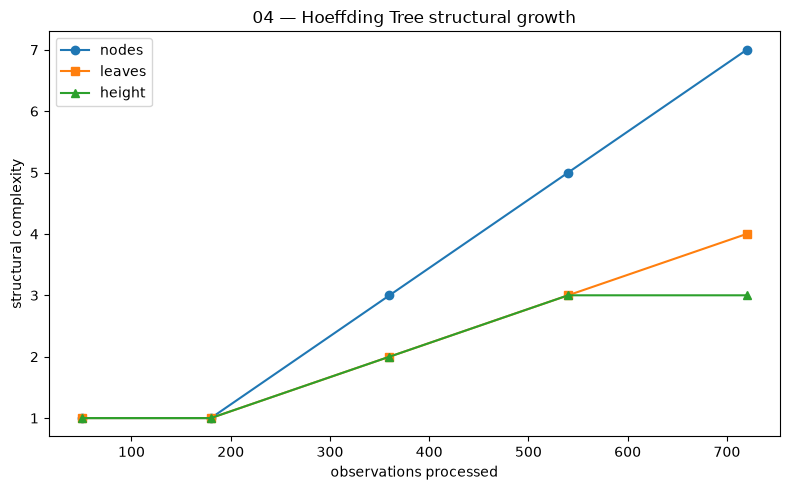

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(tree_growth_df["n"], tree_growth_df["n_nodes"], marker="o", label="nodes")
plt.plot(tree_growth_df["n"], tree_growth_df["n_leaves"], marker="s", label="leaves")
plt.plot(tree_growth_df["n"], tree_growth_df["height"], marker="^", label="height")
plt.xlabel("observations processed")
plt.ylabel("structural complexity")
plt.title("04 — Hoeffding Tree structural growth")
plt.legend()
finish_figure("04_hoeffding_tree_growth.png")

### Exercise 4 — What would a smaller `grace_period` change?

The `grace_period` controls how many observations a leaf sees between attempts to evaluate a split. What trade-off would you expect if we reduced it substantially?

<details>
<summary><strong>Show suggested answer</strong></summary>

The tree would reconsider splits more frequently, potentially reacting/growing sooner, but it would spend more computation evaluating split candidates. The Hoeffding evidence requirement still matters; more frequent checks do not guarantee a split at every check.

</details>

## 6. Public ENFS-Uni0 implementation: parameters **and** fuzzy-rule structure (~15 min)

An evolving fuzzy classifier can do two qualitatively different things:

```text
known region  → refine existing parameters
novel region  → create or reorganize structure
```

We use the **same dedicated architecture stream** as the Hoeffding Tree so that new compact regions actually arrive over time.

### Scientific naming note

The object instantiated below is the current public class:

```python
from evolvingfuzzysystems.classification import ENFS_Uni0
```

For this notebook, we label it **Public ENFS-Uni0 implementation**. This is intentionally more precise than implying that the package is a verified equation-by-equation reproduction of the original paper.

We also avoid imposing an artificially small rule ceiling: `max_rules` is increased so the graph can reveal the model's own structural behaviour instead of merely showing that it hit a limit.

> **Goal:** observe when the public evolving fuzzy implementation refines existing knowledge and when its rule base changes.

In [13]:
class ENFSAdapter:
    def __init__(self, model, n_features):
        self.model = model
        self.n_features = n_features
    def _vec(self, x):
        return np.array([x[f"x{i}"] for i in range(self.n_features)], dtype=float)
    def predict_one(self, x):
        return int(self.model.predict_one(self._vec(x)))
    def learn_one(self, x, y):
        self.model.learn_one(self._vec(x), int(y))
        return self
    def __getattr__(self, name):
        return getattr(self.model, name)


class FallbackENFS:
    """Educational evolving-rule fallback; NOT the ENFS-Uni0 algorithm."""
    def __init__(self, n_features, n_classes=2, lambda_ff=0.99,
                 sim_threshold=0.90, max_rules=30, random_state=42):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lambda_ff = lambda_ff
        self.sim_threshold = sim_threshold
        self.max_rules = max_rules
        self.rng = np.random.default_rng(random_state)
        self.rules = []
        self.history_n_rules = []
    @property
    def n_rules_(self):
        return len(self.rules)
    def _vec(self, x):
        if isinstance(x, dict): return np.array([x[f"x{i}"] for i in range(self.n_features)])
        return np.asarray(x, dtype=float).ravel()
    def predict_one(self, x):
        if not self.rules: return 0
        v = self._vec(x)
        j = int(np.argmin([np.linalg.norm(v-r["center"]) for r in self.rules]))
        return int(np.argmax(self.rules[j]["class_counts"]))
    def learn_one(self, x, y):
        v, y = self._vec(x), int(y)
        if not self.rules:
            self.rules.append({"center": v.copy(), "support": 1,
                               "class_counts": np.bincount([y], minlength=self.n_classes).astype(float)})
        else:
            d = np.array([np.linalg.norm(v-r["center"]) for r in self.rules])
            j = int(np.argmin(d))
            # Tight enough to reveal the arrival of genuinely new compact regions.
            threshold = 0.16 + 0.12*(1-self.sim_threshold)
            if d[j] > threshold and len(self.rules) < self.max_rules:
                self.rules.append({"center": v.copy(), "support": 1,
                                   "class_counts": np.bincount([y], minlength=self.n_classes).astype(float)})
            else:
                r = self.rules[j]; r["support"] += 1
                eta = max(1-self.lambda_ff, 1/r["support"])
                r["center"] = (1-eta)*r["center"] + eta*v
                r["class_counts"][y] += 1
        self.history_n_rules.append(self.n_rules_)
        return self


def make_enfs(n_features, lambda_ff=0.99, sim_threshold=0.90, max_rules=30):
    if EFS_AVAILABLE:
        m = ENFS_Uni0(n_features=n_features, n_classes=2, lambda_ff=lambda_ff,
                      sim_threshold=sim_threshold, max_rules=max_rules, random_state=SEED)
        return ENFSAdapter(m, n_features)
    return FallbackENFS(n_features=n_features, n_classes=2, lambda_ff=lambda_ff,
                        sim_threshold=sim_threshold, max_rules=max_rules, random_state=SEED)


def rule_count(model):
    for name in ("n_rules_", "n_rules", "num_rules"):
        if hasattr(model, name):
            value = getattr(model, name)
            return int(value() if callable(value) else value)
    history = getattr(model, "history_n_rules", [])
    return int(history[-1]) if history else 0


fuzzy_model = make_enfs(2, lambda_ff=0.99, sim_threshold=0.90, max_rules=30)
fuzzy_eval = StreamingBinaryEvaluator(window_size=100)
fuzzy_rows = []

for k, row in enumerate(events_arch, start=1):
    yp = fuzzy_model.predict_one(row["x"])
    fuzzy_eval.update(row["y"], yp)
    fuzzy_model.learn_one(row["x"], row["y"])
    if k in structural_checkpoints:
        fuzzy_rows.append({"n": k, "n_rules": rule_count(fuzzy_model),
                           "accuracy": fuzzy_eval.snapshot()["accuracy"]})

fuzzy_growth_df = pd.DataFrame(fuzzy_rows)
display(fuzzy_growth_df)

if int(fuzzy_growth_df["n_rules"].max()) >= 30:
    print("⚠️ Rule base reached max_rules=30; consider raising the ceiling before interpreting saturation.")

,n,n_rules,accuracy
0,50,1,1.000000
1,180,1,1.000000
2,360,6,0.994444
3,540,9,0.994444
4,720,12,0.984722


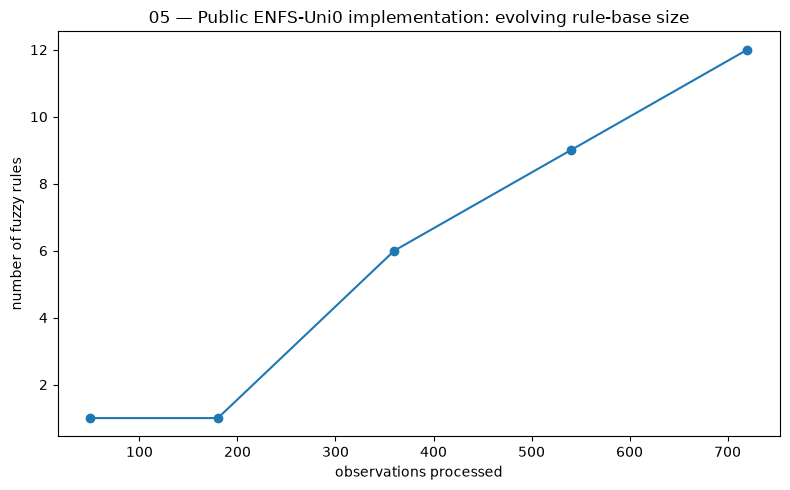

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(fuzzy_growth_df["n"], fuzzy_growth_df["n_rules"], marker="o")
plt.xlabel("observations processed")
plt.ylabel("number of fuzzy rules")
plt.title("05 — Public ENFS-Uni0 implementation: evolving rule-base size")
finish_figure("05_fuzzy_rule_growth.png")

### Exercise 5 — Parameters, architecture, and artificial ceilings

Consider three controls in the public implementation:

- `lambda_ff`: forgetting factor in consequent adaptation;
- `sim_threshold`: similarity/redundancy control affecting rule interactions;
- `max_rules`: explicit upper bound on rule-base size.

Why is it dangerous to interpret a flat `n_rules` curve when the model has already reached `max_rules`?

<details>
<summary><strong>Show suggested answer</strong></summary>

Because the curve no longer tells us that the data stopped providing structural novelty. It may only tell us that **we prohibited further structural growth**. A capacity limit is a design constraint, not evidence that the architecture naturally stabilized.

</details>

# Part III — One protocol, multiple learners
## 7. Prequential comparison on the architecture stream (~8 min)

Now all learners receive **exactly the same dedicated architecture stream** and the same Week 4 protocol.

We compare:

- GaussianNB;
- Online Logistic Regression;
- Hoeffding Tree with majority-class leaves;
- **Public ENFS-Uni0 implementation**.

This is a fair predictive comparison of the implementations actually executed. It is **not** a claim that one algorithm family is universally superior, and it is not a claim that the public fuzzy implementation is exactly equivalent to the original paper formulation.

> **Same events. Same order. Same prequential protocol. Different model states.**

In [15]:
def make_comparison_models(n_features):
    return {
        "GaussianNB": make_gaussian_nb(n_features),
        "Online Logistic": make_logistic(n_features, seed=SEED),
        "Hoeffding Tree (mc leaves)": make_tree(n_features, grace_period=20),
        "Public ENFS-Uni0 impl.": make_enfs(n_features, max_rules=30),
    }

comparison_rows = []
comparison_summary = []
for name, model in make_comparison_models(2).items():
    hist, snap, pred_s, upd_s = prequential_trace(events_arch, model, window_size=100)
    hist["model"] = name
    comparison_rows.append(hist)
    comparison_summary.append({
        "model": name,
        "accuracy": snap["accuracy"],
        "macro_f1": snap["macro_f1"],
        "prediction_ms/event": 1000*pred_s/len(events_arch),
        "update_ms/event": 1000*upd_s/len(events_arch),
    })

comparison_history = pd.concat(comparison_rows, ignore_index=True)
comparison_summary_df = pd.DataFrame(comparison_summary)
display(comparison_summary_df)

,model,accuracy,macro_f1,prediction_ms/event,update_ms/event
0,GaussianNB,0.737135,0.721570,0.188737,0.006544
1,Online Logistic,0.855556,0.855501,0.002226,0.004650
2,Hoeffding Tree (mc leaves),0.694019,0.673802,0.008676,0.012274
3,Public ENFS-Uni0 impl.,0.984722,0.984721,0.154619,0.323941


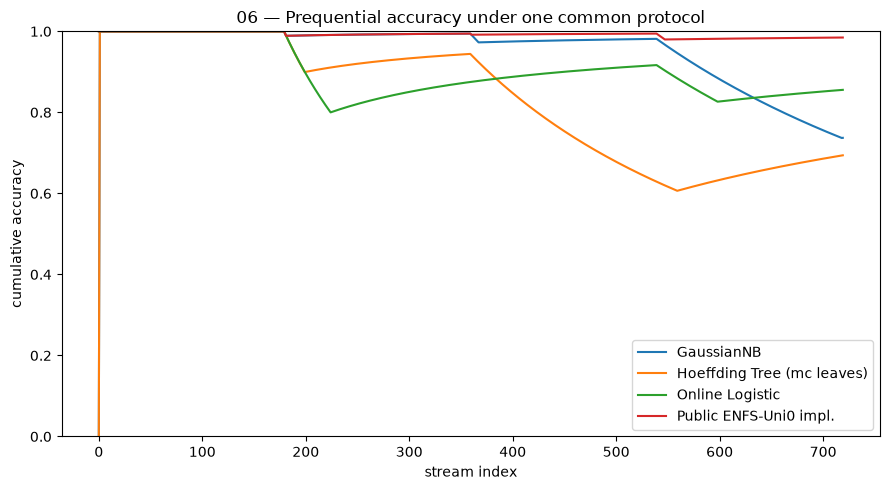

In [16]:
plt.figure(figsize=(9, 5))
for name, part in comparison_history.groupby("model"):
    plt.plot(part["i"], part["accuracy"], label=name)
plt.xlabel("stream index")
plt.ylabel("cumulative accuracy")
plt.ylim(0, 1)
plt.title("06 — Prequential accuracy under one common protocol")
plt.legend()
finish_figure("06_prequential_accuracy_all_models.png")

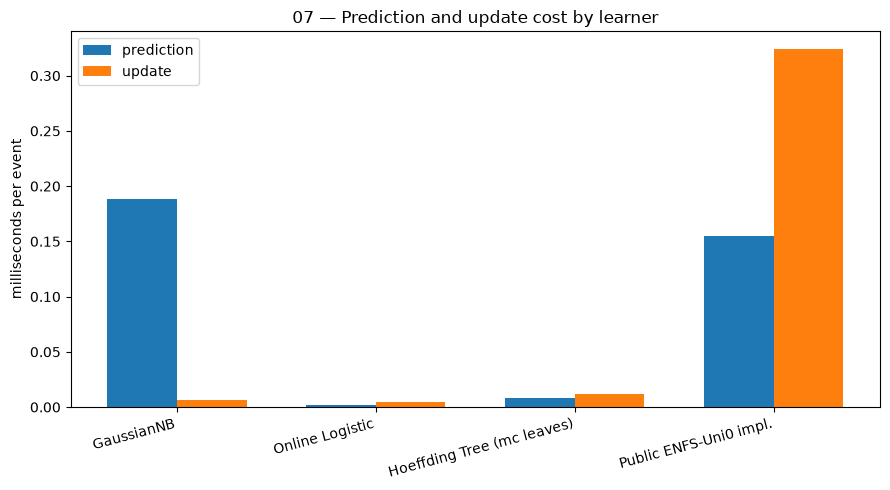

In [17]:
long_cost = comparison_summary_df.melt(
    id_vars="model",
    value_vars=["prediction_ms/event", "update_ms/event"],
    var_name="operation", value_name="milliseconds"
)
labels = list(comparison_summary_df["model"])
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x-width/2, comparison_summary_df["prediction_ms/event"], width, label="prediction")
plt.bar(x+width/2, comparison_summary_df["update_ms/event"], width, label="update")
plt.xticks(x, labels, rotation=15, ha="right")
plt.ylabel("milliseconds per event")
plt.title("07 — Prediction and update cost by learner")
plt.legend()
finish_figure("07_update_cost_by_model.png")

# Part IV — Dimensionality, then irrelevant-feature robustness
## 8. What changes at 2, 10, and 30 **informative** features? (~8 min)

The previous version of this laboratory kept only two informative dimensions and filled the remaining columns with random noise. That was not a pure dimensionality experiment — it was mainly a test of **robustness to irrelevant features**.

We now separate the questions.

### Experiment A — dimensionality

For 2D, 10D and 30D, **every feature contributes to the target**. We monitor:

- predictive performance;
- prediction/update time;
- model complexity.

### Experiment B — stress test (afterwards)

Only after the dimensionality experiment do we add nuisance features deliberately and ask:

> **How robust is each learner to irrelevant dimensions?**

These are different research questions and should not share the same interpretation.

In [18]:
def model_complexity(name, model, d):
    if name == "GaussianNB": return 2*d*2 + 2, "statistics"
    if name == "Online Logistic": return d+1, "coefficients"
    if name.startswith("Hoeffding Tree"): return tree_complexity(model)["n_nodes"], "nodes"
    if name.startswith("Public ENFS"): return rule_count(model), "rules"
    return 0, "state"


def benchmark_stream_factory(stream_factory, dimensions=(2, 10, 30), n_samples=350, seed=42):
    rows = []
    for d in dimensions:
        events = stream_factory(n_samples=n_samples, n_features=d, seed=seed)
        for name, model in make_comparison_models(d).items():
            evaluator = StreamingBinaryEvaluator(window_size=100)
            pred_s = upd_s = 0.0
            for row in events:
                t0 = perf_counter(); yp = model.predict_one(row["x"]); pred_s += perf_counter()-t0
                evaluator.update(row["y"], yp)
                t1 = perf_counter(); model.learn_one(row["x"], row["y"]); upd_s += perf_counter()-t1
            snap = evaluator.snapshot()
            complexity, label = model_complexity(name, model, d)
            rows.append({
                "dimension": d, "model": name,
                "accuracy": snap["accuracy"], "macro_f1": snap["macro_f1"],
                "prediction_ms/event": 1000*pred_s/n_samples,
                "update_ms/event": 1000*upd_s/n_samples,
                "complexity": complexity, "complexity_label": label,
            })
    return pd.DataFrame(rows)


dimension_benchmark = benchmark_stream_factory(
    make_informative_dimension_stream,
    dimensions=(2, 10, 30), n_samples=350, seed=SEED
)
display(dimension_benchmark)

,dimension,model,accuracy,macro_f1,prediction_ms/event,update_ms/event,complexity,complexity_label
0,2,GaussianNB,0.928367,0.928357,0.188712,0.006223,10,statistics
1,2,Online Logistic,0.571429,0.478110,0.001911,0.003666,3,coefficients
2,2,Hoeffding Tree (mc leaves),0.458453,0.361493,0.007206,0.016971,1,nodes
3,2,Public ENFS-Uni0 impl.,0.845714,0.845709,0.251219,0.396770,21,rules
4,10,GaussianNB,0.865330,0.865290,0.189071,0.010311,42,statistics
5,10,Online Logistic,0.488571,0.386091,0.003650,0.008249,11,coefficients
6,10,Hoeffding Tree (mc leaves),0.464183,0.460712,0.008155,0.062410,1,nodes
7,10,Public ENFS-Uni0 impl.,0.497143,0.496732,0.304051,0.446329,19,rules
8,30,GaussianNB,0.787966,0.787964,0.303292,0.030950,122,statistics
9,30,Online Logistic,0.482857,0.464384,0.003999,0.011041,31,coefficients


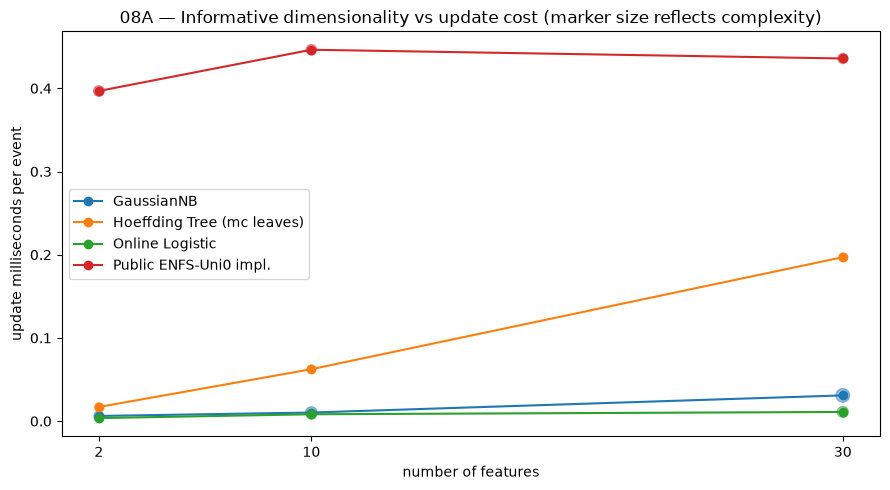

In [19]:
plt.figure(figsize=(9, 5))
for name, part in dimension_benchmark.groupby("model"):
    sizes = 30 + 6*np.sqrt(np.maximum(part["complexity"].to_numpy(), 1))
    plt.plot(part["dimension"], part["update_ms/event"], marker="o", label=name)
    plt.scatter(part["dimension"], part["update_ms/event"], s=sizes, alpha=0.45)
plt.xlabel("number of features")
plt.ylabel("update milliseconds per event")
plt.title("08A — Informative dimensionality vs update cost (marker size reflects complexity)")
plt.xticks([2, 10, 30])
plt.legend()
finish_figure("08a_informative_dimension_vs_cost_complexity.png")

### 8B. Separate stress test — irrelevant features

Now we intentionally return to the harder scenario:

```text
2D  = 2 informative features
10D = 2 informative + 8 nuisance features
30D = 2 informative + 28 nuisance features
```

This experiment should be interpreted as **irrelevant-feature robustness**, not as dimensionality alone.

This distinction is particularly important for distance- and region-based evolving models, because random dimensions change the geometry used to decide whether observations belong to existing regions.

,dimension,model,accuracy,macro_f1,prediction_ms/event,update_ms/event,complexity,complexity_label
0,2,GaussianNB,0.832776,0.832234,0.199530,0.012548,10,statistics
1,2,Online Logistic,0.500000,0.499978,0.003686,0.007119,3,coefficients
2,2,Hoeffding Tree (mc leaves),0.428094,0.427453,0.007453,0.017299,1,nodes
3,2,Public ENFS-Uni0 impl.,0.670000,0.669967,0.239301,0.382537,20,rules
4,10,GaussianNB,0.765886,0.765569,0.194800,0.010614,42,statistics
5,10,Online Logistic,0.500000,0.499911,0.002369,0.005056,11,coefficients
6,10,Hoeffding Tree (mc leaves),0.428094,0.427453,0.007972,0.062132,1,nodes
7,10,Public ENFS-Uni0 impl.,0.486667,0.485546,0.231213,0.354164,18,rules
8,30,GaussianNB,0.722408,0.721798,0.289767,0.026017,122,statistics
9,30,Online Logistic,0.513333,0.512553,0.006690,0.018495,31,coefficients


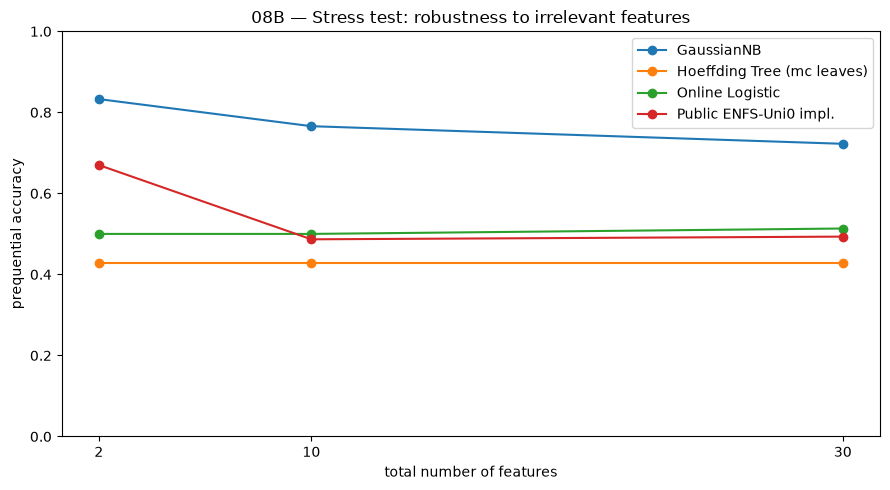

In [20]:
nuisance_benchmark = benchmark_stream_factory(
    make_nuisance_stream,
    dimensions=(2, 10, 30), n_samples=300, seed=SEED
)
display(nuisance_benchmark)

plt.figure(figsize=(9, 5))
for name, part in nuisance_benchmark.groupby("model"):
    plt.plot(part["dimension"], part["accuracy"], marker="o", label=name)
plt.xlabel("total number of features")
plt.ylabel("prequential accuracy")
plt.ylim(0, 1)
plt.title("08B — Stress test: robustness to irrelevant features")
plt.xticks([2, 10, 30])
plt.legend()
finish_figure("08b_irrelevant_feature_robustness.png")

## Interpretation checkpoint

Use the outputs above to keep **four** questions separate:

1. **Predictive:** which learner performs well on the current concept?
2. **Computational:** which learner updates quickly enough?
3. **Structural:** does the architecture actually grow, or is performance coming from a fixed structure / leaf predictor?
4. **Robustness:** what happens when irrelevant dimensions distort the input geometry?

Do not compress all four into one sentence such as *“model X scales badly.”*

A scientific interpretation should name the mechanism being tested.

In [21]:
final_table = pd.DataFrame([
    ["GaussianNB", "counts / means / variances", "No", "bounded by features × classes"],
    ["Online Logistic", "weights + bias", "No", "bounded by features"],
    ["Passive-Aggressive", "weights + bias", "No", "bounded by features"],
    ["Hoeffding Tree", "leaf statistics + nodes", "Yes", "can grow with statistically justified splits"],
    ["Public ENFS-Uni0 impl.", "public rule parameters + consequents + rules", "Yes", "can grow up to max_rules"],
], columns=["learner", "what evolves", "architecture evolves?", "state growth"])

display(final_table)

final_tree = int(tree_growth_df["n_nodes"].iloc[-1])
max_rules_seen = int(fuzzy_growth_df["n_rules"].max())
print("FINAL_DIAGNOSTICS")
print(f"tree_nodes_final={final_tree}")
print(f"public_enfs_rules_max={max_rules_seen}")
print("informative_dimensions=[2, 10, 30]")
print("nuisance_stress_dimensions=[2, 10, 30]")

if final_tree <= 1:
    print("⚠️ Architecture check: Hoeffding Tree did not grow; inspect installed River/version before class.")
if max_rules_seen <= 1:
    print("⚠️ Architecture check: public ENFS implementation did not create additional rules.")

,learner,what evolves,architecture evolves?,state growth
0,GaussianNB,counts / means / variances,No,bounded by features × classes
1,Online Logistic,weights + bias,No,bounded by features
2,Passive-Aggressive,weights + bias,No,bounded by features
3,Hoeffding Tree,leaf statistics + nodes,Yes,can grow with statistically justified splits
4,Public ENFS-Uni0 impl.,public rule parameters + consequents + rules,Yes,can grow up to max_rules


FINAL_DIAGNOSTICS
tree_nodes_final=7
public_enfs_rules_max=12
informative_dimensions=[2, 10, 30]
nuisance_stress_dimensions=[2, 10, 30]


## Final reflection

Answer these without looking only at final accuracy:

1. Which learner evolved **statistics**?
2. Which learner evolved **continuous parameters**?
3. Which learner changed parameters **conditionally**?
4. Which experiment demonstrated actual **tree architecture growth**?
5. Did the public fuzzy implementation create new rules naturally, or did it hit an imposed capacity ceiling?
6. What is the difference between **higher dimensionality** and **more irrelevant dimensions**?
7. Why do we label the fuzzy model as the **public ENFS-Uni0 implementation** rather than automatically treating it as an exact paper reproduction?

> **A benchmark is only as meaningful as the experimental question it actually isolates.**

## Bridge to Week 6 — Ensembles & Advanced Stream Classifiers

Today we compared individual incremental learners under one common protocol.

Next question:

> **Can multiple incremental learners work together to become stronger and more robust?**

```text
one learner  →  many learners  →  ensemble prediction
```

The Week 4 prequential evaluator remains useful. The Week 5 learners become the building blocks.

---
### Take-away

**A model is state too.**  
**Some learners evolve parameters. Others evolve architecture. Some evolve both.**  
**An incremental learner does not rebuild the model — it evolves the model.**